data download from this website : LitPop data (v.1.2) (TAR, 10.88Gb) of https://www.research-collection.ethz.ch/handle/20.500.11850/331316

In [2]:
!pip install pandas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Reading and cleaning the CSV data
def load_and_clean_data(filename):
    # Load CSV data
    df = pd.read_csv(filename)
    
    # Clean data: remove rows with invalid values (e.g., value <= 0)
    df = df[df['value'] > 0].dropna()
    
    # Ensure latitude and longitude are numeric
    df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Drop any rows with NaN after conversion
    df = df.dropna()
    
    return df


In [7]:
# Creating the visualization
def visualize_population_density(df):
    # Creating a figure and axis
    plt.figure(figsize=(10, 10))
    
    # Creating a scatter plot with color intensity based on population density
    scatter = plt.scatter(
        df['longitude'],
        df['latitude'],
        c=df['value'],
        s=10,
        cmap='viridis',
        norm=plt.Normalize(vmin=df['value'].min(), vmax=df['value'].quantile(0.95)),  # Cap at 95th percentile for better visualization
        alpha=0.6
    )
    
    # Adding a colorbar
    plt.colorbar(scatter, label='USD')
    
    # Setting labels and title
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Economic value of physical assets in Philippines')

    # Adding grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig("LitPop_pc_30arcsec_PHL.png")

    # Showing the plot
    plt.show()


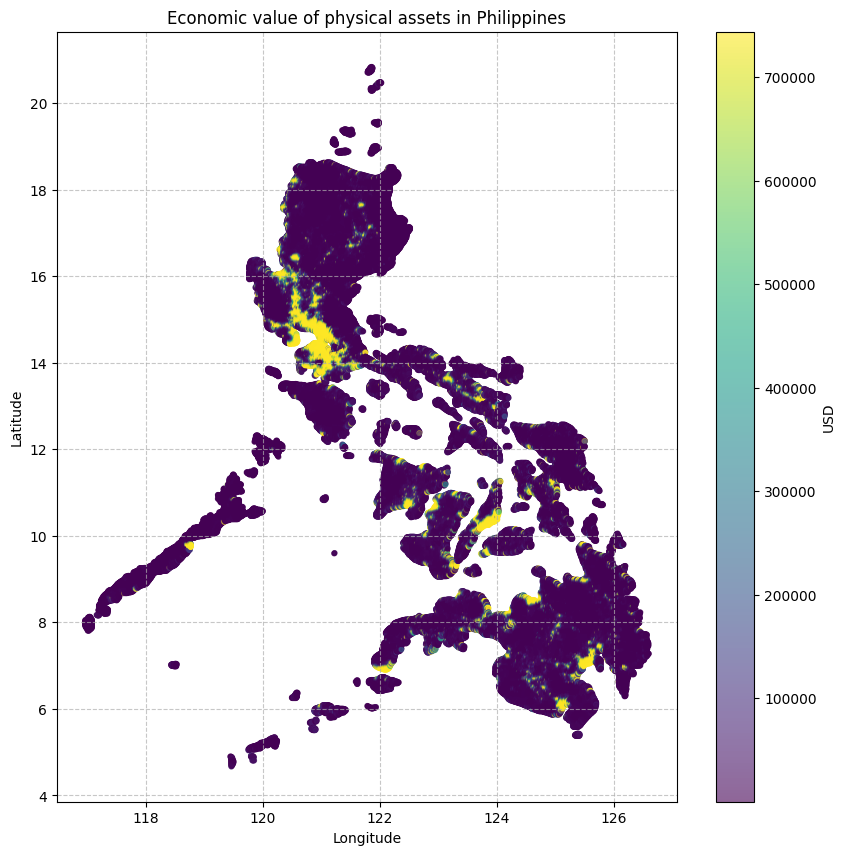

In [8]:
# Main execution
if __name__ == "__main__":
    # Loading the data
    data = load_and_clean_data('LitPop_pc_30arcsec_PHL.csv')
    
    # Visualizing the data
    visualize_population_density(data)